# Daniyal Khan || 221A061 || 19

In [ ]:
!pip install pgmpy


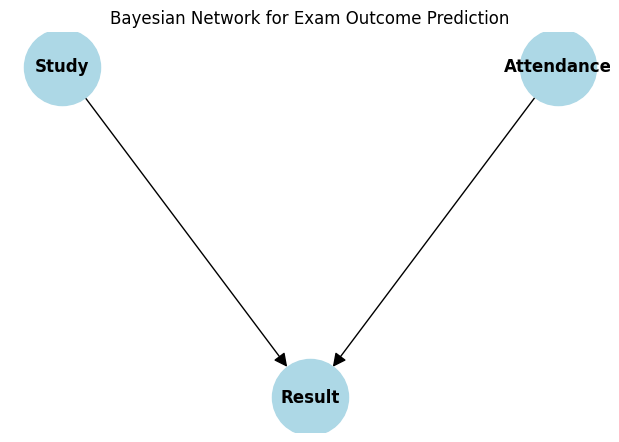


--- Exam Outcome Prediction ---
Study Status       : Studied
Attendance Status  : Good

Chances:
Fail Probability : 0.10
Pass Probability : 0.90

Final Prediction:
Student May Pass


In [9]:
# Bayesian Network for Exam Outcome Prediction

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

import networkx as nx
import matplotlib.pyplot as plt

# 1. Create the Bayesian Network structure
model = DiscreteBayesianNetwork([
    ('Study', 'Result'),
    ('Attendance', 'Result')
])

# 2. Define probability tables (CPDs)

cpd_study = TabularCPD(
    variable='Study',
    variable_card=2,
    values=[[0.4], [0.6]]
)

cpd_attendance = TabularCPD(
    variable='Attendance',
    variable_card=2,
    values=[[0.3], [0.7]]
)

cpd_result = TabularCPD(
    variable='Result',
    variable_card=2,
    values=[
        [0.9, 0.6, 0.5, 0.1],  # Fail
        [0.1, 0.4, 0.5, 0.9]   # Pass
    ],
    evidence=['Study', 'Attendance'],
    evidence_card=[2, 2]
)

# 3. Add CPDs to the model
model.add_cpds(cpd_study, cpd_attendance, cpd_result)
assert model.check_model(), "Model is incorrect"

# 4. Graph Visualization
plt.figure(figsize=(6, 4))

graph = nx.DiGraph()
graph.add_edges_from(model.edges())

pos = {
    'Study': (-1, 0),
    'Attendance': (1, 0),
    'Result': (0, -1)
}

nx.draw(
    graph,
    pos,
    with_labels=True,
    node_size=3000,
    node_color="lightblue",
    font_size=12,
    font_weight="bold",
    arrowsize=20
)

plt.title("Bayesian Network for Exam Outcome Prediction")
plt.show()

# 5. Perform inference
inference = VariableElimination(model)

# Inputs (conditions)
study = 1        # Studied
attendance = 1  # Good attendance

result = inference.query(
    variables=['Result'],
    evidence={'Study': study, 'Attendance': attendance}
)

fail_prob = result.values[0]
pass_prob = result.values[1]

print("\n--- Exam Outcome Prediction ---")
print("Study Status       : Studied")
print("Attendance Status  : Good")

print("\nChances:")
print(f"Fail Probability : {fail_prob:.2f}")
print(f"Pass Probability : {pass_prob:.2f}")

if pass_prob > fail_prob:
    print("\nFinal Prediction:")
    print("Student May Pass")
else:
    print("\nFinal Prediction:")
    print("Student May Fail")